In [2]:
import sys
import time
import os

import pandas as pd
import numpy as np
import navis
import networkx
from datetime import datetime
import pymaid
from tqdm import tqdm
import json
import random
import re
import meshparty

# For flywire -> catmaid operations
import pcg_skel
from meshparty import trimesh_vtk, trimesh_io
import skeletor 
import cloudvolume as cv
import trimesh
import trimesh as tm
import fafbseg
import caveclient

import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import seaborn as sns

import uuid

import networkx as nx
from matplotlib.lines import Line2D
from IPython.display import clear_output

D:\flywire_backup\cave\cave\lib\site-packages\blessed\terminal.py:183: UserWarning: Failed to setupterm(kind='xterm-color'): Could not find terminal xterm-color
  warnings.warn(msg)


***useful tutorial on meshparty and meshwork:***
https://tutorial.microns-explorer.org/quickstart_notebooks/00_skeletons.html

In [4]:
#megalopta project id: 8
#megalopta test project id: 25
#megalopta flywire project id: 28

path = 'D:/flywire_backup/cave/cat_client.json' # replace with your path

with open(path, 'r') as f:
    conn_file = json.load(f)
api_token = conn_file['api_token']
http_user = conn_file['http_user']
http_password = conn_file['http_password']
server = conn_file['server']

cat_client = pymaid.CatmaidInstance(server = server, 
                                api_token = api_token,
                                caching = True,
                                project_id = 8,
                                http_user = http_user,
                                http_password = http_password 
                                )


client = caveclient.CAVEclient(server_address='https://global.connectomics.braininbrain.org')
auth = client.auth

#client.info.get_datastacks()
client = caveclient.CAVEclient(datastack_name='megalopta_fb_eb_datastack')
#client = caveclient.CAVEclient(datastack_name='megalopta_pb1_datastack')

# graphene://https://local.cave.braininbrain.org/segmentation/table/megalopta_PB1_v2a
# graphene://https://local.cave.braininbrain.org/segmentation/table/megalopta_FB_EB_v3
navis.patch_cloudvolume()
vol = cv.CloudVolume('graphene://https://local.cave.braininbrain.org/segmentation/table/megalopta_FB_EB_v3', use_https=True, progress=False)

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : cloud-volume successfully patched! (navis)


### import nametable
- used to associate root ids with neuron identities

In [9]:
nametable = pd.read_csv('../syntables/updated_google_sheets/Megalopta_EB_preprint_FINAL - FBEB_EPG.csv')

nametable = nametable[['Catmaid name', 'Root ID', 'CATMAID skid']].rename(columns={'Catmaid name':'name', 'Root ID':'root_ids', 'CATMAID skid':'skid'})

nametable['skid'] = nametable['skid'].fillna(0).astype(float).astype(int)

# make sure to fill na
nametable['root_ids'] = nametable['root_ids'].fillna('').astype(str)

# convert each cell in 'root_ids' from a comma-separated string to a list of integers, ignoring empty strings
nametable['root_ids'] = nametable['root_ids'].apply(lambda x: [int(seg) for seg in x.split(',') if seg.strip()])

# remove empty values
nametable = nametable[nametable['root_ids'].apply(lambda x: len(x) > 0)].copy()

nametable = nametable[nametable['name'].str.contains(r"EPG_R8|EPG_L2")] # only include EPGs

print(nametable)

nametable_exploded = nametable.copy()
nametable_exploded = nametable_exploded.explode('root_ids')

epg_root_list = nametable_exploded['root_ids']
print()
print(epg_root_list)

           name              root_ids   skid
0  EPG_L2_55944  [576460753028086028]  55944
1  EPG_L2_55952  [576460752952978497]  55952
4  EPG_R8_56356  [576460753079329289]  56356
5  EPG_R8_56383  [576460753204982208]  56383
6  EPG_R8_55936  [576460753083932794]  55936
7  EPG_R8_64276  [576460753112188991]  64276

0    576460753028086028
1    576460752952978497
4    576460753079329289
5    576460753204982208
6    576460753083932794
7    576460753112188991
Name: root_ids, dtype: object


### import synapse table
- will be linked to neurons later on (this is work around while materialization engine is offline)

In [21]:
# import synapse table and generate random unique IDs for each synapse
# takes a min, probably a better way to do this...

syntable = pd.read_csv('../syntables/table_csv_files/megalopta_cx_syntable_21-03-26.csv')

syntable = syntable[syntable['roi'].str.contains(r'EB')]

for c in tqdm([c for c in syntable.columns if 'coords' in c or 'vox' in c]): 
    syntable[c] = syntable[c].apply(lambda s: tuple(map(int, s.strip('()').split(','))))

syntable = syntable[syntable['pre_skid'] != syntable['post_skid']] #remove autapses

syntable.head(5)

# Function to generate unique random connector IDs
def unique_id_generator(existing_ids: set, size: int = 7) -> str:
    """Creates a random unique string of digits of the specified length."""
    while True:
        first_digit = random.choice('123456789')  # Ensures the first digit is not '0'
        remaining_digits = ''.join(random.choice('0123456789') for _ in range(size - 1))
        new_id = first_digit + remaining_digits
        if new_id not in existing_ids:  # Check uniqueness
            existing_ids.add(new_id)
            return new_id

syntable['connector_id'] = None

# Set to track unique IDs
existing_ids = set(syntable['connector_id'].dropna())  # Include existing non-null IDs if any

# Apply unique ID generator
syntable['connector_id'] = syntable['connector_id'].apply(
    lambda x: unique_id_generator(existing_ids) if pd.isnull(x) else x
)

syntable["connector_id"] = syntable["connector_id"].astype(int)

syntable.head()

0it [00:00, ?it/s]


,pre_skid,post_skid,pre_name,post_name,pre_coord,post_coord,roi,pre_root_ids,post_root_ids,type_pre_col,type_post_col,type_pre,type_post,connector_id
0,NaN,NaN,NaN,NaN,"(19151, 15985, 1290)","(19126, 15985, 1291)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,3833203
1,NaN,NaN,NaN,NaN,"(19166, 15985, 1295)","(19150, 15980, 1297)",EB,576460753050011843,576460753050011843,NaN,NaN,NaN,NaN,4497889
2,NaN,NaN,NaN,NaN,"(19151, 15794, 1303)","(19160, 15816, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,4159603
3,NaN,NaN,NaN,NaN,"(19161, 15792, 1302)","(19138, 15808, 1302)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,2323468
4,NaN,NaN,NaN,NaN,"(19149, 15787, 1303)","(19163, 15797, 1303)",EB,576460753121451657,576460753121451657,NaN,NaN,NaN,NaN,6000688


# Skeletonize neuron mesh 
- I've tried this using two methods:
- Option 1 downloads meshses w/ cloudvolume and skeletonizes locally using skeletor. Synapses are then snapped to closest node position. This produces poor skeletons (many bristles/fragments/etc) - however these skeletons have perfect node radius when viewed in 3D that approximates their original 3D structure as meshes.
- Option 2 uses pcg_skel package and downloads meshwork objects from CAVE and takes advantage of meshwork / meshparty functions. Meshwork objects maintain neuron skeleton / mesh / and annotations integrated together. So far, this produces near perfect skeletons, but very poor radius approximations...

For now, EDC plots in Figure 2 rely on option 2 and are based only on geodesic information (e.g., not proper electronic distance since neuron fibre diameters (aka node raidii) are not reliable).

##  OPTION 1: download mesh w/ cloudvolume, skeletonize locally, snap synapses to node by coordinates

In [24]:
# separate nametable into two df: one with only single segids and another with lists of segids

# Split into neurons with a single root ID vs. multiple root IDs
oneRoot = nametable[nametable['root_ids'].apply(lambda x: len(x) == 1)]
multiRoot = nametable[nametable['root_ids'].apply(lambda x: len(x) > 1)]

# Extract the single root ID from each row
oneRoot_list = [x[0] for x in oneRoot['root_ids']]

# Keep the full list of segids for multi-root neurons
multiRoot_list = multiRoot['root_ids'].tolist()


# download neurons that have single root id
oneRoot_m = []

for idx, neuron in enumerate(oneRoot_list, start = 1):
    m = vol.mesh.get(neuron, remove_duplicate_vertices=True, as_navis=True)
    oneRoot_m.append(m)
    sys.stdout.write(f'\r{idx}/{len(oneRoot_list)} neuron mesh with single root downloaded.') # update console with progress
    sys.stdout.flush()

# download and fuse neurons that have multiple unmerged root ids


multiRoot_id_list = []
multiRoot_m = []

for idx, neuron in enumerate(multiRoot_list, start=1):
    first_root = neuron[0]  # get first element in the list
    m = vol.mesh.get(first_root, remove_duplicate_vertices=True, fuse=True, as_navis=True)
    multiRoot_m.append(m)
    multiRoot_id_list.append(first_root)
    sys.stdout.write(f'\r{idx}/{len(multiRoot_list)} neuron mesh (first root only) downloaded.')

oneRoot_m = navis.NeuronList(oneRoot_m)
multiRoot_m = navis.NeuronList(multiRoot_m)
multiRoot_m.set_neuron_attributes(multiRoot_id_list, name='id')

# merge oneRoot_m and multiRoot_m meshNeuronLists

# Check if both exist in the global namespace
if 'oneRoot_m' in globals() and 'multiRoot_m' in globals():
    m = oneRoot_m + multiRoot_m
    print(f'Combined list contains {len(m)} mesh neurons.')
elif 'oneRoot_m' in globals():
    m = oneRoot_m
    print(f'Combined list contains {len(m)} mesh neurons.')
elif 'multiRoot_m' in globals():
    m = multiRoot_m
    print(f'Combined list contains {len(m)} mesh neurons.')


6/6 neuron mesh with single root downloaded.Combined list contains 6 mesh neurons.


In [25]:
m

,type,name,id,units,n_vertices,n_faces
0,navis.MeshNeuron,None,576460753028086028,1 nanometer,987504,1969043
1,navis.MeshNeuron,None,576460752952978497,1 nanometer,1333049,2663034
...,...,...,...,...,...,...
4,navis.MeshNeuron,None,576460753083932794,1 nanometer,1512065,3016792
5,navis.MeshNeuron,None,576460753112188991,1 nanometer,885464,1767779


In [26]:
skel = m.copy()  # update metadata

for neuron in skel:
    root_id = neuron.id  # keep as integer
    sk_row = nametable[nametable['root_ids'].apply(lambda ids: root_id in ids)]
    
    if not sk_row.empty:
        name = sk_row['name'].values[0]
        skid = str(int(sk_row['skid'].values[0]))
        neuron.id = skid
        neuron.name = f"{name}"
        print(neuron.name)


EPG_L2_55944
EPG_L2_55952
EPG_R8_56356
EPG_R8_56383
EPG_R8_55936
EPG_R8_64276


In [27]:
# simplify
m_simp = navis.simplify_mesh(skel, 0.3, backend='pyfqmr', inplace=False, parallel=True, progress=True) #lower value, more simple

Simplifying:   0%|          | 0/6 [00:00<?, ?it/s]

In [28]:
# skeletonize

skel_list = []
# for neuron in m_simp:
#     skel = fafbseg.flywire.skeletonize_neuron(neuron) 
#     skel_list.append(skel)

for mesh in m_simp:
    sk = navis.skeletonize(mesh)
    skel_list.append(sk)

skel_list = navis.NeuronList(skel_list)

# then join aka 'heal' unjoined fragments
sk_h_list = []

for idx, neuron in enumerate(skel_list, start=1):
    if len(neuron.root) > 1: # number of disconnected fragments
        skel_h = navis.heal_skeleton(neuron)
        skel_h.soma = None
        sk_h_list.append(skel_h)
        print(f'\r{idx}/{len(skel_list)} skeleton healed')
        sys.stdout.flush()

sk_h_list = navis.NeuronList(sk_h_list)

sk_h_list

1/6 skeleton healed
2/6 skeleton healed
3/6 skeleton healed
4/6 skeleton healed
5/6 skeleton healed
6/6 skeleton healed


,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,navis.TreeNeuron,EPG_L2_55944,55944,21328,None,2567,2826,6.397237e+06,None,1 nanometer
1,navis.TreeNeuron,EPG_L2_55952,55952,29354,None,3391,3808,8.859485e+06,None,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
4,navis.TreeNeuron,EPG_R8_55936,55936,30005,None,3609,4106,9.085885e+06,None,1 nanometer
5,navis.TreeNeuron,EPG_R8_64276,64276,19064,None,2104,2343,5.654857e+06,None,1 nanometer


In [175]:
sk_list = sk_h_list.copy()

for neuron in sk_list:
    root_id = neuron.id  # keep as integer
    sk_row = nametable[nametable['root_ids'].apply(lambda ids: root_id in ids)]
    
    if not sk_row.empty:
        skid = str(int(sk_row['skid'].values[0]))
        neuron.id = skid
        print(neuron.name, neuron.id)

,type,name,id,units,n_vertices,n_faces
0,navis.MeshNeuron,EPG_L2_55944,55944,1 nanometer,296724,590712
1,navis.MeshNeuron,EPG_L2_55952,55952,1 nanometer,401592,798909
...,...,...,...,...,...,...
4,navis.MeshNeuron,EPG_R8_55936,55936,1 nanometer,453299,905037
5,navis.MeshNeuron,EPG_R8_64276,64276,1 nanometer,266329,530332


(<Figure size 800x800 with 1 Axes>, <Axes: >)

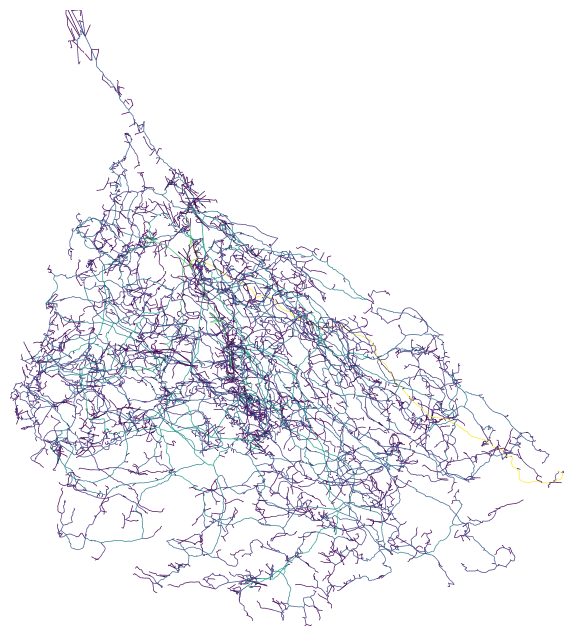

In [176]:
# Plot as lines
# skeleton needs to be cleaned...try navis functions and also skeletor package (haven't had much luck myself)
n = sk_list[1].copy

navis.plot2d(
    n, color_by="strahler_index", palette="viridis", view=("x", "-z"), method="2d", soma=True
)

## OPTION 2: use pcg_skel to download meshwork neurons, convert to navis tree neurons, snap synapses 
- produces great skeletons with poor radii estimations (likely a solution to this I haven't found already included in mesh party functions...)

In [224]:
root_ids = []
for roots in nametable['root_ids']:
    root_ids.extend(roots)

root_ids

[576460753028086028,
 576460752952978497,
 576460753079329289,
 576460753204982208,
 576460753083932794,
 576460753112188991]

In [452]:
meshworks = []

for root in root_ids:
    s = pcg_skel.pcg_meshwork(root_id=root, client=client) #there's also function: pcg_skeleton one could try
    print(f"downloaded skeleton for root_id: {root}")
    meshworks.append(s)

Minishard Indices: 100%|███████████████████████████████████████████████████████| 90/90 [00:06<00:00, 13.56it/s]


downloaded skeleton for root_id: 576460753028086028


Minishard Indices: 100%|█████████████████████████████████████████████████████| 161/161 [00:08<00:00, 19.13it/s]


downloaded skeleton for root_id: 576460752952978497


Minishard Indices: 100%|█████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.34it/s]


...

downloaded skeleton for root_id: 576460753204982208


Minishard Indices: 100%|█████████████████████████████████████████████████████| 130/130 [00:06<00:00, 18.96it/s]


downloaded skeleton for root_id: 576460753083932794


Minishard Indices: 100%|███████████████████████████████████████████████████████| 82/82 [00:04<00:00, 18.39it/s]


downloaded skeleton for root_id: 576460753112188991


In [454]:
for mw in meshworks:
    pcg_skel.features.add_volumetric_properties(mw, client=client)
    pcg_skel.features.add_segment_properties(mw)
    
# NOTE: while not used for now, "effective node radius" can found here: s.anno.segment_properties['r_eff']


In [455]:
def r_eff_nm_per_skel_vertex(mw, agg="median"):
    # Segment properties table
    df = mw.anno.segment_properties.df.copy()

    # Map each row (mesh-indexed) to skeleton vertex index
    df["skel_index"] = mw.anno.segment_properties.mesh_index.to_skel_index_padded
    df = df[df["skel_index"] >= 0]

    # Aggregate r_eff per skeleton vertex
    if agg == "median":
        r = df.groupby("skel_index")["r_eff"].median()
    elif agg == "mean":
        r = df.groupby("skel_index")["r_eff"].mean()
    else:
        raise ValueError("agg must be 'median' or 'mean'")

    # Put into a dense vector aligned with skeleton vertex indices 0..n-1
    out = np.full(mw.skeleton.n_vertices, np.nan, dtype=float)
    sk = r.index.to_numpy(dtype=int)
    out[sk] = r.to_numpy()

    # Fill any missing entries conservatively (common for special/root nodes):
    # - if you prefer, replace with neighbour-averaging along the graph
    # - here we default to global median as a safe fallback
    missing = np.isnan(out)
    if missing.any():
        out[missing] = np.nanmedian(out)

    return out


In [468]:
meshworks[0].seg_id

576460753028086028

In [471]:
from pathlib import Path

out_dir = Path("./swc")
out_dir.mkdir(exist_ok=True, parents=True)

id_to_name = {}

for _, row in nametable.iterrows(): # for looking up neuron names
    roots = row['root_ids']
    if not isinstance(roots, list):
        roots = [roots]
    for r in roots:
        id_to_name[r] = row['name']


for mw in meshworks:
    radius_nm = r_eff_nm_per_skel_vertex(mw, agg="median")

    # Optional: compartment labels (0=undefined, 1=soma) - set root as soma
    labels = np.zeros(mw.skeleton.n_vertices, dtype=int)
    labels[int(mw.skeleton.root)] = 1
    
    root_id = mw.seg_id
    name = id_to_name.get(root_id, f"unknown_{root_id}")
    
    mw.skeleton.export_to_swc(
        filename=str(out_dir / f"{name}.swc"),
        node_labels=labels,
        radius=radius_nm,
        xyz_scaling=1
    )


In [499]:
# imoprt as navis TreeNeuron

neurons = []
for fn in os.listdir(out_dir):
    if fn.endswith(".swc"):
        n = navis.read_swc(out_dir / fn)
        n.name = fn.replace(".swc", "")
        # You can keep "nm" implicit, or set explicit units if your NAVis version supports it
        # n.units = "1 nm"
        neurons.append(n)

neurons = navis.NeuronList(neurons)

name_to_skid = {}

for _, row in nametable.iterrows():
    name_to_skid[row['name']] = row['skid']

for n in neurons:
    n.id = name_to_skid.get(n.name, f"unknown_{n.name}")

In [500]:
# unable to merge these two fragments (EPG_R8_56383) due to unresolved CAVE issue (NoneType error)
# need to drop from list 

indices_to_remove = [4]
neurons = navis.NeuronList([n for i, n in enumerate(neurons) if i not in indices_to_remove])
neurons

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin
0,navis.TreeNeuron,EPG_L2_55944,55944,975,None,87,101,2775573.50,[0],1 dimensionless,2026-03-29 23:14:19.070116,swc\EPG_L2_55944.swc
1,navis.TreeNeuron,EPG_L2_55952,55952,1389,None,133,160,3776151.00,[0],1 dimensionless,2026-03-29 23:14:19.082107,swc\EPG_L2_55952.swc
...,...,...,...,...,...,...,...,...,...,...,...,...
3,navis.TreeNeuron,EPG_R8_56356,56356,1357,None,116,141,3829983.50,[0],1 dimensionless,2026-03-29 23:14:19.106133,swc\EPG_R8_56356.swc
4,navis.TreeNeuron,EPG_R8_64276,64276,903,None,77,92,2533844.75,[0],1 dimensionless,2026-03-29 23:14:19.129100,swc\EPG_R8_64276.swc


(<Figure size 800x800 with 1 Axes>, <Axes: >)

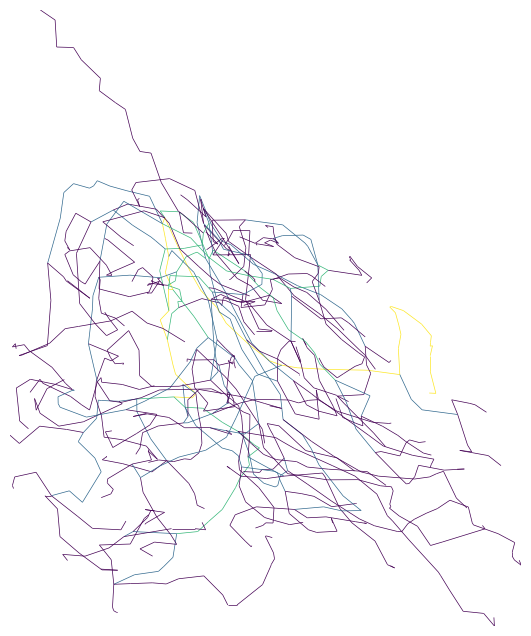

In [485]:
navis.plot2d(
    neurons[0], color_by="strahler_index", palette="viridis", view=("x", "-z"), method="2d", soma=True
)

## snap syanpses to closest node

In [501]:
# link connectors (synapses) to neurons
def parse_position(pos):
    if isinstance(pos, str):
        # Remove any enclosing brackets or parentheses
        pos = pos.strip("[]()")
        
        # Split on comma or whitespace
        parts = re.split(r'[,\s]+', pos.strip())
        
        try:
            return [int(p) for p in parts if p]
        except ValueError:
            return [np.nan, np.nan, np.nan]
    
    elif isinstance(pos, (list, tuple, np.ndarray)):
        return list(pos)
    
    else:
        return [np.nan, np.nan, np.nan]

sk_list = neurons.copy()

for n in sk_list:
    skid = int(n.id)
    cotable = syntable[(syntable['pre_skid'] == skid) | (syntable['post_skid'] == skid)]
        
    if cotable.empty:
        print('No connectors found for the following skid(s):')
        print(skid)
        print()
        continue        

    #────────────────────────────────────────────────────────
    # Process pre_matches
    pre_matches = cotable[cotable['pre_skid'] == skid].copy()
    pre_matches['type'] = 'pre'
    pre_matches['parsed_pos'] = pre_matches['pre_coord'].apply(parse_position)
    pre_matches[['x', 'y', 'z']] = pd.DataFrame(
        pre_matches['parsed_pos'].tolist(), index=pre_matches.index
    )

    #────────────────────────────────────────────────────────
    # Process post_matches
    post_matches = cotable[cotable['post_skid'] == skid].copy()
    post_matches['type'] = 'post'
    post_matches['parsed_pos'] = post_matches['post_coord'].apply(parse_position)
    post_matches[['x', 'y', 'z']] = pd.DataFrame(
        post_matches['parsed_pos'].tolist(), index=post_matches.index
    )

    #────────────────────────────────────────────────────────
    # Merge pre and post
    cotable = pd.concat([
        pre_matches[['type', 'x', 'y', 'z', 'connector_id']], 
        post_matches[['type', 'x', 'y', 'z', 'connector_id']]
    ], ignore_index=True)

    cotable.insert(0, "node_id", None)

    cotable[['x', 'y', 'z']] = cotable[['x', 'y', 'z']].astype(float)

    n.connectors = cotable.copy()

    cotable['type'] = pd.Categorical(cotable['type'], categories=['pre', 'post'])

    # Scale from voxels to nanometers
    n.connectors['x'] = n.connectors['x'] * 10
    n.connectors['y'] = n.connectors['y'] * 10
    n.connectors['z'] = n.connectors['z'] * 50

    n.connectors['locs'] = n.connectors[['x', 'y', 'z']].values.tolist()

    # Function to snap locs to nearest node
    def apply_snap(row):
        loc = row['locs']
        node_id, dist = n.snap(loc, to='nodes')
        return pd.Series([node_id, dist])

    n.connectors[['node_id', 'dist']] = n.connectors.apply(apply_snap, axis=1)

# final output:
sk_list


,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin
0,navis.TreeNeuron,EPG_L2_55944,55944,975,5227,87,101,2775573.50,[0],1 dimensionless,2026-03-29 23:14:19.070116,swc\EPG_L2_55944.swc
1,navis.TreeNeuron,EPG_L2_55952,55952,1389,7341,133,160,3776151.00,[0],1 dimensionless,2026-03-29 23:14:19.082107,swc\EPG_L2_55952.swc
...,...,...,...,...,...,...,...,...,...,...,...,...
3,navis.TreeNeuron,EPG_R8_56356,56356,1357,9450,116,141,3829983.50,[0],1 dimensionless,2026-03-29 23:14:19.106133,swc\EPG_R8_56356.swc
4,navis.TreeNeuron,EPG_R8_64276,64276,903,5397,77,92,2533844.75,[0],1 dimensionless,2026-03-29 23:14:19.129100,swc\EPG_R8_64276.swc


- for future: use synapse flow centrality to determine most likely spike initiation zone

### prune neuron to EB mesh bbox

In [502]:
# import EB mesh and create bounding box
# note: somehow cave neuron coordinates already match CATMAID coordinates, no conversion needed

eb_m = pymaid.get_volume(['EB'], remote_instance=cat_client)

'''create bbox from EB mesh'''
bbox = eb_m.bbox
# Extract min and max points using neuron bbox
x_min, x_max = bbox[0][0], bbox[1][0]
y_min, y_max = bbox[0][1], bbox[1][1]
z_min, z_max = bbox[0][2], bbox[1][2]

# Generate 8 corners of the bounding box
bbox_corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max]
])

# Create a Trimesh box from the corners
mesh_bbox = trimesh.convex.convex_hull(bbox_corners)

mesh_bbox

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


<trimesh.Trimesh(vertices.shape=(8, 3), faces.shape=(12, 3))>

In [ ]:
# check mesh coordinate line up with skeleton
fig=navis.plot3d([sk_list[0], mesh_bbox], color=['red', (0.3,0.3,0.3,0.1)])

In [565]:
# 0, 1 = y min only
# 2, 3, 4, 5, 6 = min x
# 3, 4 same neuron...
print('for EPG_L2, root should be min y')
print('for EPG_R8, root should be min x')

# sk_list = skel_list.copy()
nRooted_list = []

# Define the L2 EPGs
l2_epg = ['EPG_L2_55944', 'EPG_L2_55952']

for n in sk_list:
    nRooted = n.copy()
    nRooted.nodes['radius'] = nRooted.nodes['radius'].replace(0, 50)  # avoid zero-radius nodes

    if len(nRooted.root) == 1:
        if nRooted.name in l2_epg:
            # Use min y for EPG_L2s
            minY = nRooted.nodes.loc[nRooted.nodes['y'].idxmin()]
            node_id = minY['node_id']
            axis = 'y'
        else:
            # Use min x otherwise
            minX = nRooted.nodes.loc[nRooted.nodes['x'].idxmin()]
            node_id = minX['node_id']
            axis = 'x'

        nRooted = navis.reroot_skeleton(nRooted, node_id)
        nRooted.soma = nRooted.root
        nRooted.soma_radius = 2000
        print(f'{nRooted.name} root set to min {axis}')
        print(f'new root: {nRooted.root}; new soma: {nRooted.soma}, resized to {nRooted.soma_radius}')
    else:
        print(f'{nRooted.name} has multiple roots, soma not set')

    nRooted_list.append(nRooted)

nRooted_list = navis.NeuronList(nRooted_list)



for EPG_L2, root should be min y
for EPG_R8, root should be min x
EPG_L2_55944 root set to min y
new root: [850]; new soma: [850], resized to 2000
EPG_L2_55952 root set to min y
new root: [1288]; new soma: [1288], resized to 2000
EPG_R8_55936 root set to min x
new root: [699]; new soma: [699], resized to 2000
EPG_R8_56356 root set to min x
new root: [740]; new soma: [740], resized to 2000
EPG_R8_64276 root set to min x
new root: [826]; new soma: [826], resized to 2000


In [ ]:
# Check root is correct
eb_m.color = (120, 120, 120, 0.1)
fig=navis.plot3d([nRooted_list[3], eb_m], soma=True, color_by="strahler_index", palette="viridis", color=(0.3,0.3,0.3,0.1), alpha=1)
#fig=navis.plot3d([nRooted_list[3], eb_m], radius=True)

In [100]:
nRooted_list[0].nodes

,node_id,x,y,z,radius,type,parent_id,strahler_index
0,0,280624.172396,253159.491060,210068.067950,56.597939,slab,24971,7
1,1,275998.515053,209281.569370,190697.439670,122.664345,slab,24736,2
2,2,275924.685086,209080.759094,191914.130429,88.222449,slab,24763,1
3,3,278220.868270,206653.511951,191091.878224,50.000000,slab,20,2
4,4,280256.948707,259217.317298,206731.120972,107.484767,slab,24982,1
...,...,...,...,...,...,...,...,...
21323,25007,281259.989412,260316.637977,206609.048137,149.722657,slab,25003,1
21324,25008,281214.612860,260455.057477,206548.633717,86.562658,end,25007,1
21325,25009,281378.640473,253386.450508,209866.328876,217.916959,slab,25004,1
21326,25010,281441.219516,253437.225803,209872.920270,108.958480,end,25009,1


In [108]:
# calculate geodesic distance to root
for n in nRooted_list: 
    distRoot = navis.dist_to_root(n, weight='weight')
    n.connectors['distRoot'] = n.connectors['node_id'].map(distRoot)

nRooted_list[0].connectors # should see column distRoot

### generate geodesic matrix and eDist

In [566]:
def add_edist_to_connectors(n):
    n = n.copy()
    nodes = n.nodes.copy()
    connectors = n.connectors.copy()

    cols = ["node_id", "parent_id", "x", "y", "z", "radius"]
    nodes = nodes[cols].copy()

    parents = nodes[["node_id", "x", "y", "z"]].rename(columns={
        "node_id": "parent_id",
        "x": "px",
        "y": "py",
        "z": "pz"
    })

    nodes = nodes.merge(parents, on="parent_id", how="left")

    # Euclidean edge length to parent
    nodes["seg_len"] = np.sqrt(
        (nodes["x"] - nodes["px"])**2 +
        (nodes["y"] - nodes["py"])**2 +
        (nodes["z"] - nodes["pz"])**2
    )
    nodes.loc[nodes["parent_id"] == -1, "seg_len"] = 0.0

    # If radius = half-width, then width = 2 * radius
    # Your paper says lambda is based on width of the edge.
    nodes["length_constant"] = np.sqrt(nodes["radius"] / 2)
    # equivalent to sqrt((2*radius)/4)

    # electrotonic distance of each edge = edge length / length constant
    nodes["eDist_segment"] = np.where(
        nodes["seg_len"] > 0,
        nodes["seg_len"] / nodes["length_constant"],
        0.0
    )

    parent_dict = dict(zip(nodes["node_id"], nodes["parent_id"]))
    seg_edist_dict = dict(zip(nodes["node_id"], nodes["eDist_segment"]))

    dist_to_root = {}

    def compute_dist_to_root_iter(node_id):
        path = []
        current = node_id

        while current not in dist_to_root:
            path.append(current)
            parent = parent_dict.get(current, -1)
            if parent == -1:
                dist_to_root[current] = 0.0
                break
            current = parent

        while path:
            child = path.pop()
            parent = parent_dict.get(child, -1)
            if parent == -1:
                dist_to_root[child] = 0.0
            else:
                dist_to_root[child] = dist_to_root[parent] + seg_edist_dict.get(child, 0.0)

        return dist_to_root[node_id]

    connectors["eDist"] = connectors["node_id"].map(compute_dist_to_root_iter)

    emin = connectors["eDist"].min()
    emax = connectors["eDist"].max()
    if emax > emin:
        connectors["normEDist"] = (connectors["eDist"] - emin) / (emax - emin)
    else:
        connectors["normEDist"] = 0.0

    n.connectors = connectors
    return n


# Process all neurons automatically
nRooted_list = [add_edist_to_connectors(n) for n in nRooted_list]

In [567]:
nRooted_list[0].connectors

,node_id,type,x,y,z,connector_id,locs,dist,eDist,normEDist
0,847.0,pre,226810.0,169950.0,145700.0,3539342,"[226810.0, 169950.0, 145700.0]",1690.502884,420.821899,0.035763
1,847.0,pre,226920.0,170260.0,145850.0,1196894,"[226920.0, 170260.0, 145850.0]",1957.779354,420.821899,0.035763
2,842.0,pre,233210.0,180210.0,154200.0,3076436,"[233210.0, 180210.0, 154200.0]",1125.788612,1126.060043,0.095696
3,841.0,pre,234830.0,182930.0,156650.0,7272809,"[234830.0, 182930.0, 156650.0]",1837.688766,1298.265579,0.110331
4,841.0,pre,234880.0,182900.0,156650.0,7778759,"[234880.0, 182900.0, 156650.0]",1876.938997,1298.265579,0.110331
...,...,...,...,...,...,...,...,...,...,...
5222,131.0,post,280110.0,259480.0,206550.0,9335748,"[280110.0, 259480.0, 206550.0]",1748.084666,10408.581160,0.884555
5223,131.0,post,281200.0,260300.0,206800.0,3695887,"[281200.0, 260300.0, 206800.0]",2454.791233,10408.581160,0.884555
5224,131.0,post,280190.0,257840.0,207400.0,6295754,"[280190.0, 257840.0, 207400.0]",377.491722,10408.581160,0.884555
5225,131.0,post,280410.0,257510.0,207750.0,3294512,"[280410.0, 257510.0, 207750.0]",608.194048,10408.581160,0.884555


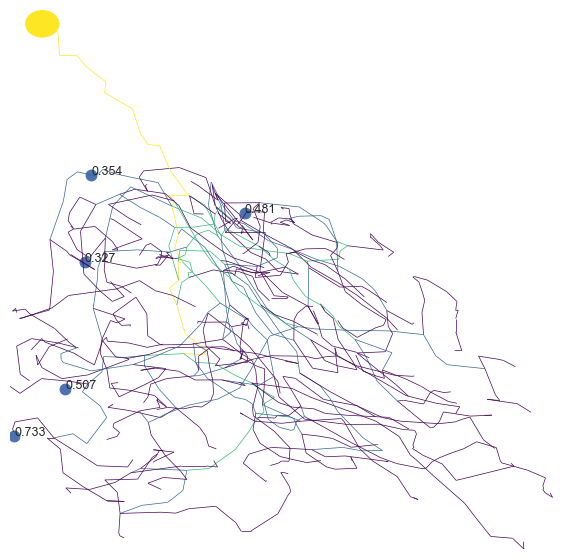

In [569]:
# verify this worked by randomly plotting some connectors alongisde their metrics

# choose neuron
idx = 0

# choose view
view = ("x", "-z") 

n = nRooted_list[idx]

# choose 5 random connectors
sample = n.connectors.sample(5, random_state=1).copy()

def project_coords(df, view):
    def get_axis(v):
        if v.startswith("-"):
            return -df[v[1:]].values
        else:
            return df[v].values

    return get_axis(view[0]), get_axis(view[1])

fig, ax = plt.subplots(figsize=(7, 7))
navis.plot2d(n, ax=ax, color_by="strahler_index", palette="viridis", method="2d", view=view, color="lightgray")

x, y = project_coords(sample, view)

ax.scatter(x, y, s=60)

for xi, yi, (_, row) in zip(x, y, sample.iterrows()):
    ax.text(xi, yi, f"{row['normEDist']:.3f}", fontsize=9)

plt.show()

In [570]:
# save connector table withe elctrotonic distance measurements to save time later
for n in nRooted_list:
    conntable = n.connectors
    conntable.to_csv(f'./edc_tables/{n.name}_conntable_edc.csv') 


In [304]:
epg = sk_list[0]

skid = epg.id    

cat_n = pymaid.get_neuron(skid, with_connectors=False, remote_instance=cat_client)


cat_n.nodes['radius'] = 500 # arbitrary backbone radius (doesn't matter for calculation)
to_stitch = cat_n + epg
stitched = navis.stitch_skeletons(to_stitch)

epgStitched = stitched.copy()

# set new root at base of neuron (to bypass an annoying byproduct of skeletonizing the cell)
minX = epgStitched.nodes.loc[epgStitched.nodes['x'].idxmin()]
node_id = minX['node_id']
epgStitched = navis.reroot_skeleton(epgStitched, node_id)
epgStitched.root

# separate mainFiber from branches to obtain list of root nodes
mainFiber = navis.longest_neurite(epgStitched)
branches = navis.longest_neurite(epgStitched, inverse=True)




INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


In [ ]:
# check that it worked
navis.clear3d()
fig=navis.plot3d([mainFiber, branches], colors=['b', (0.3,0.3,0.3,0.1)], radius=True)

In [307]:
'''prune for multi root'''
eb_m = pymaid.get_volume(['EB'], remote_instance=cat_client)

bbox = eb_m.bbox
# Extract min and max points using neuron bbox
x_min, x_max = bbox[0][0], bbox[1][0]
y_min, y_max = bbox[0][1], bbox[1][1]
z_min, z_max = bbox[0][2], bbox[1][2]

# Generate 8 corners of the bounding box
bbox_corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max]
])

# Create a Trimesh box from the corners
mesh_bbox = trimesh.convex.convex_hull(bbox_corners)

mesh_bbox
# cat_pruned = navis.in_volume(cat_n, mesh_bbox, mode='OUT')

# nRooted = navis.prune_twigs(n, size=2000) # removes connectors attached to prunned twigs
nRooted = navis.in_volume(epgStitched, mesh_bbox, mode='IN')
mainRooted = navis.in_volume(mainFiber, mesh_bbox, mode='IN')

nPruned.nodes['radius'] = nPruned.nodes['radius'].replace(0, 10) # smallest node size shouldn't be 0. 10 is arbitrary

# Obtain list of root nodes
mainFiber_nodelist = mainPruned.nodes['node_id'].to_list()

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


In [ ]:
# # calculate geodesic distance to root
# distRoot = navis.dist_to_root(nRooted, weight='weight')
# nRooted.connectors['distRoot'] = nRooted.connectors['node_id'].map(distRoot)

# nPruned.connectors

In [317]:
n = nPruned.copy()
adj = navis.geodesic_matrix(n, directed=False, weight='weight')
adj

,4133084,4128400,4128403,4128423,4126443,4129030,4126054,4126055,4126056,4126057,...,36323,36325,36328,36329,36333,36334,36335,36336,36337,36338
4133084,0.000000,108333.084922,108583.735180,105481.082875,116603.831340,68334.714329,152103.461339,151953.962175,152274.121820,152430.806217,...,238411.516175,238048.831275,236233.927861,236449.278428,237685.952248,237364.069253,237207.283233,237063.739363,236782.391879,236913.327064
4128400,108333.084922,0.000000,250.650259,2852.002047,132176.731970,40821.304414,167676.361968,167526.862804,167847.022449,168003.706846,...,253984.416804,253621.731904,251806.828491,252022.179057,253258.852877,252936.969882,252780.183862,252636.639992,252355.292508,252486.227693
4128403,108583.735180,250.650259,0.000000,3102.652305,132427.382228,41071.954672,167927.012226,167777.513062,168097.672708,168254.357104,...,254235.067063,253872.382163,252057.478749,252272.829316,253509.503136,253187.620140,253030.834121,252887.290251,252605.942766,252736.877951
4128423,105481.082875,2852.002047,3102.652305,0.000000,129324.729923,37969.302367,164824.359921,164674.860757,164995.020403,165151.704799,...,251132.414757,250769.729857,248954.826444,249170.177010,250406.850830,250084.967835,249928.181815,249784.637945,249503.290461,249634.225646
4126443,116603.831340,132176.731970,132427.382228,129324.729923,0.000000,92178.361377,148988.324805,148838.825642,149158.985287,149315.669683,...,210890.068691,210527.383790,208712.480377,208927.830943,210164.504763,209842.621768,209685.835748,209542.291878,209260.944394,209391.879579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36334,237364.069253,252936.969882,253187.620140,250084.967835,209842.621768,212938.599289,269748.562718,269599.063554,269919.223199,270075.907596,...,1047.446923,684.762022,1130.141391,914.790825,321.882995,0.000000,156.786020,300.329890,581.677374,450.742189
36335,237207.283233,252780.183862,253030.834121,249928.181815,209685.835748,212781.813269,269591.776698,269442.277534,269762.437180,269919.121576,...,1204.232942,841.548042,973.355372,758.004805,478.669015,156.786020,0.000000,143.543870,424.891354,293.956169
36336,237063.739363,252636.639992,252887.290251,249784.637945,209542.291878,212638.269400,269448.232828,269298.733664,269618.893310,269775.577706,...,1347.776812,985.091912,829.811502,614.460935,622.212885,300.329890,143.543870,0.000000,281.347485,150.412300
36337,236782.391879,252355.292508,252605.942766,249503.290461,209260.944394,212356.921915,269166.885344,269017.386180,269337.545825,269494.230221,...,1629.124297,1266.439396,548.464017,333.113451,903.560369,581.677374,424.891354,281.347485,0.000000,130.935185


In [318]:
# -----------------------------------------------------------------------------
# 1. PREPARE DICTIONARIES FOR PARENT AND RADIUS LOOKUPS
# -----------------------------------------------------------------------------

parent_dict = dict(zip(n.nodes["node_id"], n.nodes["parent_id"]))
radius_dict = dict(zip(n.nodes["node_id"], n.nodes["radius"]))

# -----------------------------------------------------------------------------
# 2. CREATING A CACHE FOR DISTANCE-TO-ROOT
# -----------------------------------------------------------------------------
#
#   dist_to_root[node_id] = (float) total electrotonic distance from node_id up to the root
#
dist_to_root = {}  # empty dictionary, filled on-the-fly

# -----------------------------------------------------------------------------
# 3. DEFINE A RECURSIVE FUNCTION TO COMPUTE DISTANCE FROM A NODE TO THE ROOT
# -----------------------------------------------------------------------------

def compute_dist_to_root(node_id, parent_dict, radius_dict, adj):
    """
    Recursively compute the electrotonic distance from 'node_id' to the root node.
    
    node_id     : The ID of the node whose distance I want.
    parent_dict : Dictionary mapping node_id -> parent_id.
    radius_dict : Dictionary mapping node_id -> radius.
    adj         : A Pandas DataFrame (or similar) where adj.loc[id1, id2] 
                  gives the length of the edge between id1 and id2.
    Returns:
        A float representing the electrotonic distance from node_id to the root.
    """
    
    # If we've already computed it, return the cached value
    if node_id in dist_to_root:
        return dist_to_root[node_id]
    
    # If for some reason this node is not in parent_dict, can't proceed
    if node_id not in parent_dict:
        dist_to_root[node_id] = 0.0
        return 0.0

    parent_id = parent_dict[node_id]

    # If this node is the root (parent_id == -1), distance = 0
    if parent_id in mainFiber_nodelist:
        dist_to_root[node_id] = 0.0
        return 0.0

    # Otherwise, compute the parent's distance to root (recursive call)
    parent_distance = compute_dist_to_root(parent_id, parent_dict, radius_dict, adj)
    
    # Now add the segment distance from node_id to its parent
    # 1. Retrieve morphological distance from adjacency
    dist = adj.loc[node_id, parent_id]
    
    # 2. Get this node's radius
    #    (If radius missing, assume 0 or something. For now, assume it's there.)
    radius = radius_dict[node_id]
    
    # 3. Compute length constant: λ = sqrt(diameter / 4), where diameter = 2 * radius
    length_constant = np.sqrt((radius * 2) / 4)
    
    # 4. Electrotonic distance for this segment
    eDist_segment = length_constant / dist
    
    # 5. Summation
    total_dist = parent_distance + eDist_segment
    
    # Save in the cache
    dist_to_root[node_id] = total_dist
    return total_dist

# -----------------------------------------------------------------------------
# 4. DEFINE THE PER-ROW FUNCTION FOR CONNECTORS
# -----------------------------------------------------------------------------

def calculate_eDist_for_row(row, parent_dict, radius_dict, adj):
    """
    For a single connector row, compute the eDist from that connector's node_id to the root.
    row          : A row from nPruned.connectors
    parent_dict  : Dictionary mapping node_id -> parent_id
    radius_dict  : Dictionary mapping node_id -> radius
    adj          : Adjacency DataFrame for morphological distances
    """
    node_id = row["node_id"]
    return compute_dist_to_root(node_id, parent_dict, radius_dict, adj)

# -----------------------------------------------------------------------------
# 5. APPLY THIS FUNCTION ACROSS ALL CONNECTORS
# -----------------------------------------------------------------------------

# This will invoke calculate_eDist_for_row() on each row of nPruned.connectors.
# Because now have caching (dist_to_root) and dictionaries for O(1) lookups,
# this should be *much* faster than repeated .loc filtering on large DataFrames.
n.connectors["eDist"] = n.connectors.apply(
    lambda row: calculate_eDist_for_row(row, parent_dict, radius_dict, adj),
    axis=1
)

n.connectors

,node_id,connector_id,type,x,y,z,locs,dist,eDist
0,14765.0,7818007,pre,242120.0,245860.0,175150.0,"[242120.0, 245860.0, 175150.0]",885.098895,25.482446
1,14332.0,5036449,pre,240510.0,250370.0,173100.0,"[240510.0, 250370.0, 173100.0]",235.739126,27.529319
2,21594.0,5598554,pre,248430.0,190370.0,193950.0,"[248430.0, 190370.0, 193950.0]",21.591096,42.643037
3,11964.0,6816179,pre,236760.0,199500.0,211750.0,"[236760.0, 199500.0, 211750.0]",1352.778758,45.753367
4,11594.0,8621843,pre,236900.0,188580.0,161000.0,"[236900.0, 188580.0, 161000.0]",453.872229,33.006508
...,...,...,...,...,...,...,...,...,...
712,6094.0,7675588,post,229230.0,230240.0,195100.0,"[229230.0, 230240.0, 195100.0]",471.720700,51.799820
713,24762.0,5667396,post,252100.0,274230.0,182400.0,"[252100.0, 274230.0, 182400.0]",125.070368,48.260522
714,29975.0,3178944,post,260340.0,199130.0,185000.0,"[260340.0, 199130.0, 185000.0]",435.995611,34.824845
715,32474.0,2150750,post,265240.0,196360.0,199550.0,"[265240.0, 196360.0, 199550.0]",585.776949,50.343365


In [319]:
# normalize eDist
# If 'eDist' is your electrotonic distance, for example:
n.connectors['normEDist'] = (n.connectors['eDist'] - n.connectors['eDist'].min()) / n.connectors['eDist'].max()
n.connectors


,node_id,connector_id,type,x,y,z,locs,dist,eDist,normEDist
0,14765.0,7818007,pre,242120.0,245860.0,175150.0,"[242120.0, 245860.0, 175150.0]",885.098895,25.482446,0.290173
1,14332.0,5036449,pre,240510.0,250370.0,173100.0,"[240510.0, 250370.0, 173100.0]",235.739126,27.529319,0.326277
2,21594.0,5598554,pre,248430.0,190370.0,193950.0,"[248430.0, 190370.0, 193950.0]",21.591096,42.643037,0.592855
3,11964.0,6816179,pre,236760.0,199500.0,211750.0,"[236760.0, 199500.0, 211750.0]",1352.778758,45.753367,0.647716
4,11594.0,8621843,pre,236900.0,188580.0,161000.0,"[236900.0, 188580.0, 161000.0]",453.872229,33.006508,0.422884
...,...,...,...,...,...,...,...,...,...,...
712,6094.0,7675588,post,229230.0,230240.0,195100.0,"[229230.0, 230240.0, 195100.0]",471.720700,51.799820,0.754365
713,24762.0,5667396,post,252100.0,274230.0,182400.0,"[252100.0, 274230.0, 182400.0]",125.070368,48.260522,0.691938
714,29975.0,3178944,post,260340.0,199130.0,185000.0,"[260340.0, 199130.0, 185000.0]",435.995611,34.824845,0.454957
715,32474.0,2150750,post,265240.0,196360.0,199550.0,"[265240.0, 196360.0, 199550.0]",585.776949,50.343365,0.728675


In [571]:
# add partner names to connector tables using syntable
# remove pre (only interested in inputs to EPGs, not in EPGs outputs to other neurons)
n_conn = nRooted_list.copy()
for n in n_conn: 
    
    n.connectors = n.connectors[~n.connectors['type'].str.contains("pre", na=False)]
    
    n.connectors['partner_name'] = None
    
    # Loop through the DataFrame and update the 'partner_name' column
    for index, row in n.connectors.iterrows():
        try:
            partner_name = syntable.loc[syntable["connector_id"] == row["connector_id"], "type_pre"].iloc[0]
        except IndexError:
            partner_name = None  # Handle cases where no match is found
        n.connectors.at[index, 'partner_name'] = partner_name

# remove ExR
for n in n_conn: 
    n.connectors = n.connectors[~n.connectors['partner_name'].str.contains(r'ExR', na=False)]

C:\Users\Marcel\AppData\Local\Temp\ipykernel_3932\2389282830.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Marcel\AppData\Local\Temp\ipykernel_3932\2389282830.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [572]:
n_conn[0].connectors['partner_name'].unique()

array([nan, 'EPG', 'PEG', 'MBUv', 'PEN_b', 'PEN_a', 'MBUd', 'LBU', 'LAL'],
      dtype=object)

# Plot

In [586]:
color_dict = {
    'PEN_a': '#EEA700',
    'PEN_b': '#63BCFA',
    'LAL': '#CC655B',
    'LBU': '#51C9CB',
    'MBUv': "#FFA500",
    'MBUd': '#9355E1',
    'EPG': '#34B887',
    'PEG': '#EF506C'
}

In [582]:
# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), 'plots')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

plt.rcParams['pdf.fonttype'] = 'truetype'

Directory already exists: D:\Github\bee-ant-head-direction\analysis\plots


### normalized normEDist CDF plot (all neurons)

In [587]:
all_conn = pd.concat([n.connectors for n in n_conn]).reset_index(drop=True)

In [588]:
core = all_conn[all_conn['partner_name'].str.contains(r'EPG|PEG|PEN_a|PEN_b', na=False)]
er = all_conn[~all_conn['partner_name'].str.contains(r'EPG|PEG|PEN_a|PEN_b', na=False)]

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\CORE_averaged_R8-L2_cdf_normEDist_30-03-26.pdf


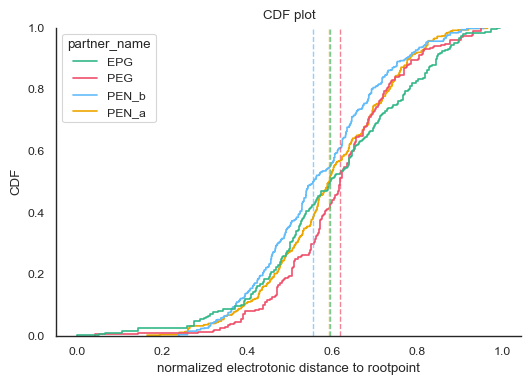

In [589]:
# Set a style/theme roughly analogous to theme_paper()
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = core.groupby('partner_name')['normEDist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=core,
    x="normEDist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("normalized electrotonic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"CORE_averaged_R8-L2_cdf_normEDist_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\ER_averaged_R8-L2_cdf_normEDist_30-03-26.pdf


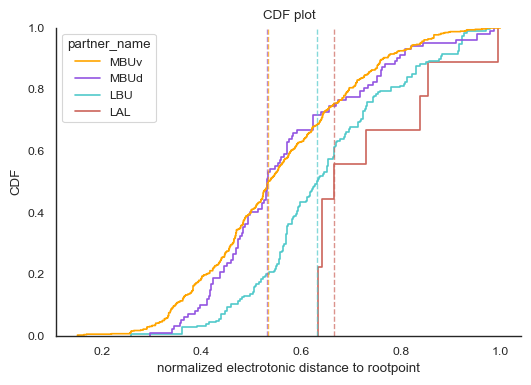

In [590]:
# Set a style/theme roughly analogous to theme_paper()
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = er.groupby('partner_name')['normEDist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=er,
    x="normEDist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("normalized electrotonic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"ER_averaged_R8-L2_cdf_normEDist_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

### geodesic distance to root point cdf plots

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\CORE_averaged_R8-L2_cdf_geodesic_distance_30-03-26.pdf


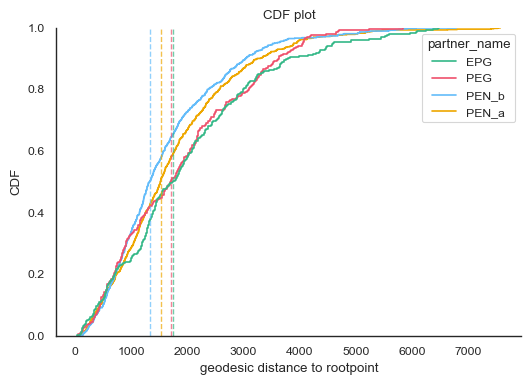

In [592]:
# Set a style/theme roughly analogous to theme_paper()
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = core.groupby('partner_name')['dist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=core,
    x="dist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("geodesic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"CORE_averaged_R8-L2_cdf_geodesic_distance_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\ER_averaged_R8-L2_cdf_geodesic_distance_30-03-26.pdf


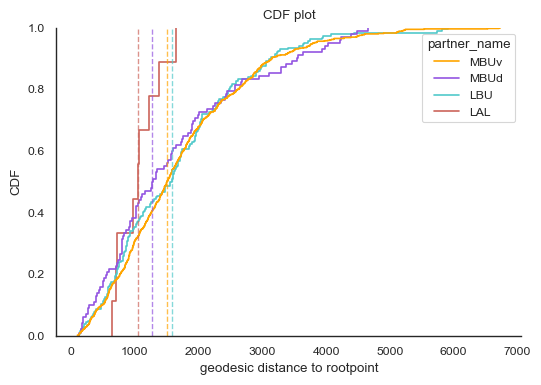

In [593]:
# Set a style/theme roughly analogous to theme_paper()
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(context="paper", style="white", rc=custom_params)

medians = er.groupby('partner_name')['dist'].median()

# Create an ECDF plot
plt.figure(figsize=(6, 4))
sns.ecdfplot(
    data=er,
    x="dist",
    hue="partner_name",       # analogous to color=modality in R
    palette=color_dict        # custom color dict from your code
)
plt.xlabel("geodesic distance to rootpoint")
plt.ylabel("CDF")
plt.title(f"CDF plot")
# plt.legend(title="Modality")

# Overlay vertical lines for medians
for partner, median_val in medians.items():
    plt.axvline(x=median_val,
                linestyle='--',
                linewidth=1,
                color=color_dict.get(partner, 'gray'),
                alpha=0.7,
                label=f"{partner} median")


# Construct the filename and save the plot
fig_name = f"ER_averaged_R8-L2_cdf_geodesic_distance_{today}.pdf"
file_path = os.path.join(save_dir, fig_name)
plt.savefig(file_path, bbox_inches = 'tight', pad_inches=0, format='pdf')
print(f"Plot saved: {file_path}")


plt.show()

-----------------------------------------------------------------------------------------

In [106]:
# Load example neurons
d7 = [
    390222,
    390337,
    390342,
    390322,
    390312,
    390352,
    390267,
    390212,
    390252,
    390362,
    390302,
    390372,
    390272,
    390207,
    390227,
    390357,
    390262,
    390377,
    390327,
    390287,
    390347,
    390217,
    390292,
    390297,
    390257,
    390232,
    390282,
    390177,
    390237,
    390382,
    390332,
    390307,
    390247,
    390317,
    390172,
    390277,
    390167,
    390242,
    390367
]

nl = pymaid.get_neuron(d7, with_connectors=False, remote_instance=megalopta_flywire)

nl



Fetch neurons:   0%|          | 0/39 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/39 [00:00<?, ?it/s]

,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,delta7_L6_R3_41_FS_86277,390222,8037,0,749,798,4335699.00,None,1 nanometer
1,CatmaidNeuron,delta7_L6_R3_82632,390337,8447,0,708,765,4527355.50,None,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
37,CatmaidNeuron,delta7_R_L4_R5_FS_84303,390242,5895,0,544,580,3117661.25,None,1 nanometer
38,CatmaidNeuron,delta7_R_L4_R5_SH_FS_81522,390367,4156,0,402,435,2198877.00,None,1 nanometer


In [ ]:
# Reroot to soma
nl_nm[nl_nm.soma != None].reroot(nl_nm[nl_nm.soma != None].soma, inplace=True)

In [117]:
max_row = nl[0].nodes.loc[nl[0].nodes['x'].idxmax()]
max_row.node_id 

for neuron in nl: 
    soma_row = neuron.nodes.loc[neuron.nodes['x'].idxmax()]
    neuron.soma = soma_row.node_id

nl

,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,delta7_L6_R3_41_FS_86277,390222,8037,0,749,798,4335699.00,6551004,1 nanometer
1,CatmaidNeuron,delta7_L6_R3_82632,390337,8447,0,708,765,4527355.50,6680376,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
37,CatmaidNeuron,delta7_R_L4_R5_FS_84303,390242,5895,0,544,580,3117661.25,6573495,1 nanometer
38,CatmaidNeuron,delta7_R_L4_R5_SH_FS_81522,390367,4156,0,402,435,2198877.00,6717591,1 nanometer


reroot:   0%|          | 0/39 [00:00<?, ?it/s]

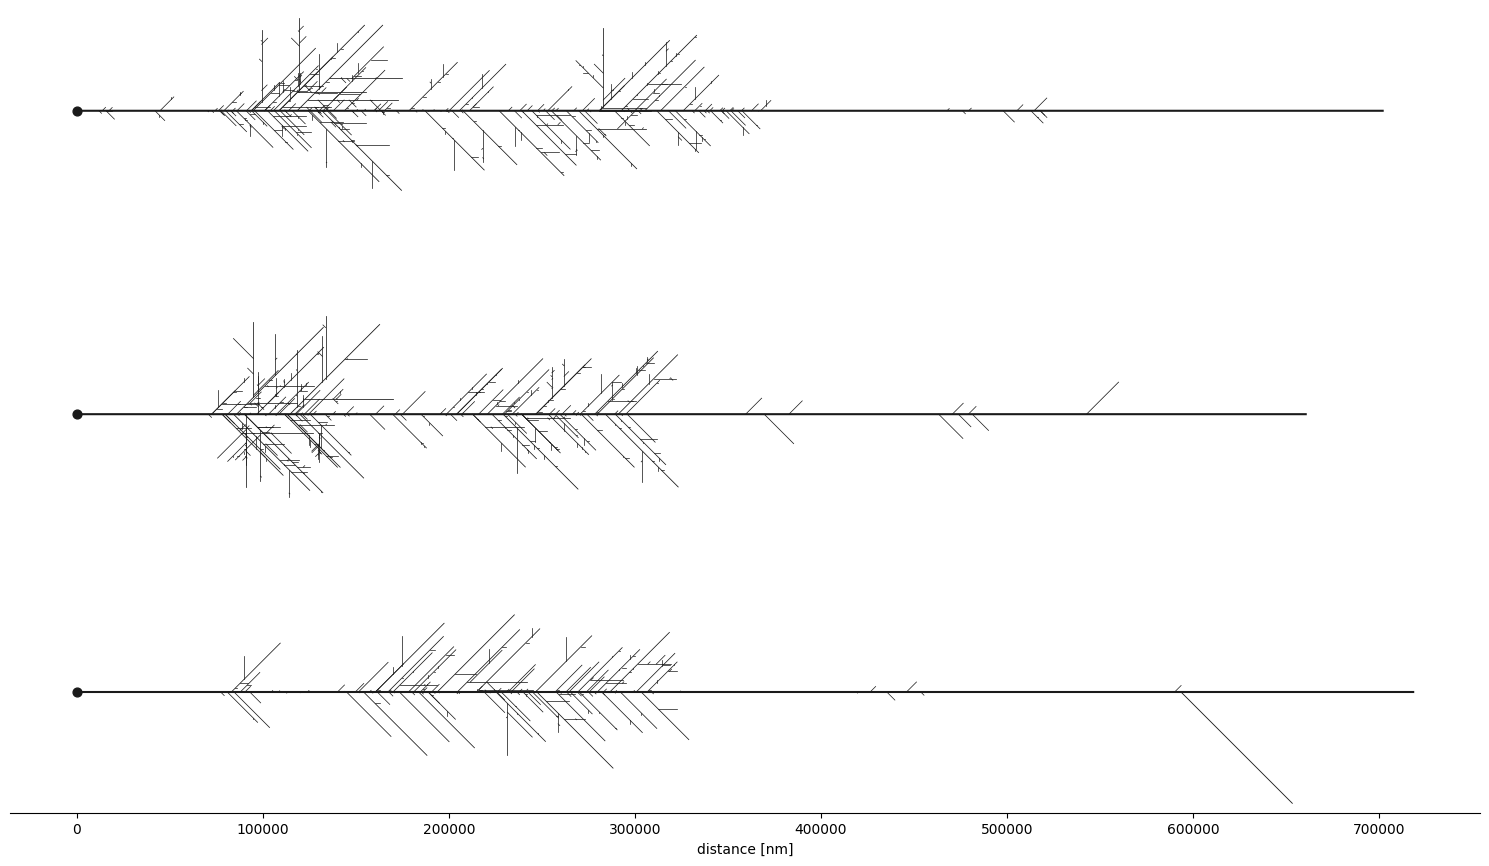

In [120]:
# # Convert example neurons from voxels to nanometers
# nl_nm = nl.convert_units("nm")

# Reroot to soma
nl[nl.soma != None].reroot(nl[nl.soma != None].soma, inplace=True)

# Generate one axis for each neuron
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

navis.plot_flat(nl[0], layout="subway", connectors=True, ax=axes[0])
navis.plot_flat(nl[1], layout="subway", connectors=True, ax=axes[1])
navis.plot_flat(nl[3], layout="subway", connectors=True, ax=axes[2])

# Clean up the axes
for ax in axes[:-1]:
    ax.set_axis_off()

for sp in ["left", "right", "top"]:
    axes[-1].spines[sp].set_visible(False)
axes[-1].set_yticks([])

_ = axes[-1].set_xlabel("distance [nm]")
plt.tight_layout()